# Graficos para o relatorio - RL Thymio

Este notebook le o ficheiro `results.csv`, seleciona os modelos principais e gera graficos em PNG para usar no relatorio.

Dependencias sugeridas:

```bash
pip install pandas matplotlib seaborn
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

RESULTS_PATH = Path("results.csv")
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

df = pd.read_csv(RESULTS_PATH)
df.head()

,experiment,model,activation,environment,ablation,training_timesteps,evaluation_episodes,mean_covered_area_m2,total_collisions,total_falls,total_cliff_terminations,mean_reward_start,mean_reward_end,reward_improvement
0,ppo_tanh_random_full,PPO,Tanh,random,none,20480,5,0.0135,0,4,NaN,-83.877275,-97.936729,-14.059454
1,recurrent_tanh_random_full,RecurrentPPO,Tanh,random,none,20480,5,0.0150,0,5,NaN,-58.783718,-57.869164,0.914554
2,recurrent_tanh_random_reward_v2,RecurrentPPO,Tanh,random,none,20480,5,0.0720,0,0,5.0,-0.779890,4.364188,5.144077
3,ppo_tanh_random_reward_v2,PPO,Tanh,random,none,20480,5,0.0720,0,0,5.0,13.446049,-10.087136,-23.533185
4,ppo_tanh_v2_10penaltyFallCliff,PPO,Tanh,random,none,20480,5,0.0560,1,0,NaN,31.889338,11.926886,-19.962453


## Selecionar os modelos principais

A ideia e focar os modelos que contam melhor a historia do projeto:

- melhor modelo final: PPO + Tanh + random;
- comparacao de ativacao: PPO + ReLU + random;
- comparacao de arquitetura: RecurrentPPO + Tanh + random;
- comparacao de ambiente: PPO + Tanh treinado em standard e avaliado em random;
- baseline/ablacao: v3.1 com cliff warning mais simples.

In [ ]:
selected_experiments = [
    "ppo_tanh_random_simple_antispin_stuck_50k",
    "ppo_relu_random_simple_antispin_stuck_50k",
    "recurrent_tanh_random_simple_antispin_stuck_50k",
    "ppo_tanh_standard_simple_antispin_stuck_50k",
    "ppo_tanh_random_cliff_warning_v3.1",
]

labels = {
    "ppo_tanh_random_simple_antispin_stuck_50k": "PPO Tanh Random",
    "ppo_relu_random_simple_antispin_stuck_50k": "PPO ReLU Random",
    "recurrent_tanh_random_simple_antispin_stuck_50k": "RecurrentPPO Tanh Random",
    "ppo_tanh_standard_simple_antispin_stuck_50k": "PPO Tanh Standard",
    "ppo_tanh_random_cliff_warning_v3.1": "PPO Tanh v3.1",
}

notes = {
    "ppo_tanh_random_simple_antispin_stuck_50k": "Maior area e zero eventos; visualmente conservador, rodando mais no centro.",
    "ppo_relu_random_simple_antispin_stuck_50k": "Recuava ao chegar ao precipicio de frente, mas explorou pouco.",
    "recurrent_tanh_random_simple_antispin_stuck_50k": "Movimento curvo para a direita; continuou com quedas e pouca estabilidade.",
    "ppo_tanh_standard_simple_antispin_stuck_50k": "Andava de costas e terminou por stuck/cliff.",
    "ppo_tanh_random_cliff_warning_v3.1": "Fazia curvas, mas terminava cedo por cliff warning; boa baseline de seguranca rigida.",
}

main = df[df["experiment"].isin(selected_experiments)].copy()
main["label"] = main["experiment"].map(labels)
main["visual_observation"] = main["experiment"].map(notes)

numeric_columns = [
    "mean_covered_area_m2",
    "total_collisions",
    "total_falls",
    "total_cliff_terminations",
    "mean_reward_start",
    "mean_reward_end",
    "reward_improvement",
]

for column in numeric_columns:
    main[column] = pd.to_numeric(main[column], errors="coerce").fillna(0)

main["total_safety_events"] = (
    main["total_collisions"]
    + main["total_falls"]
    + main["total_cliff_terminations"]
)

main = main.set_index("experiment").loc[selected_experiments].reset_index()
main

,experiment,model,activation,environment,ablation,training_timesteps,evaluation_episodes,mean_covered_area_m2,total_collisions,total_falls,total_cliff_terminations,mean_reward_start,mean_reward_end,reward_improvement,label,visual_observation,total_safety_events
0,ppo_tanh_random_simple_antispin_stuck_50k,PPO,Tanh,random,none,50000,5,0.144,0,0,0.0,-78.780519,-66.493893,12.286626,PPO Tanh Random,Maior area e zero eventos; visualmente conserv...,0.0
1,ppo_relu_random_simple_antispin_stuck_50k,PPO,ReLU,random,none,50000,5,0.056,1,0,0.0,-71.266960,-80.571398,-9.304438,PPO ReLU Random,"Recuava ao chegar ao precipicio de frente, mas...",1.0
2,recurrent_tanh_random_simple_antispin_stuck_50k,RecurrentPPO,Tanh,random,none,50000,5,0.072,1,3,1.0,-109.798568,-173.808710,-64.010142,RecurrentPPO Tanh Random,Movimento curvo para a direita; continuou com ...,5.0
3,ppo_tanh_standard_simple_antispin_stuck_50k,PPO,Tanh,standard,none,50000,5,0.096,0,0,5.0,-108.358661,-117.717028,-9.358368,PPO Tanh Standard,Treinado em standard e avaliado em random; and...,5.0
4,ppo_tanh_random_cliff_warning_v3.1,PPO,Tanh,random,none,20480,5,0.096,0,0,3.0,18.431409,-8.783563,-27.214971,PPO Tanh v3.1,"Fazia curvas, mas terminava cedo por cliff war...",3.0


## 1. Area media coberta

Este grafico mostra diretamente a metrica principal de exploracao.

C:\Users\Ravi\AppData\Local\Temp\ipykernel_7228\483833462.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


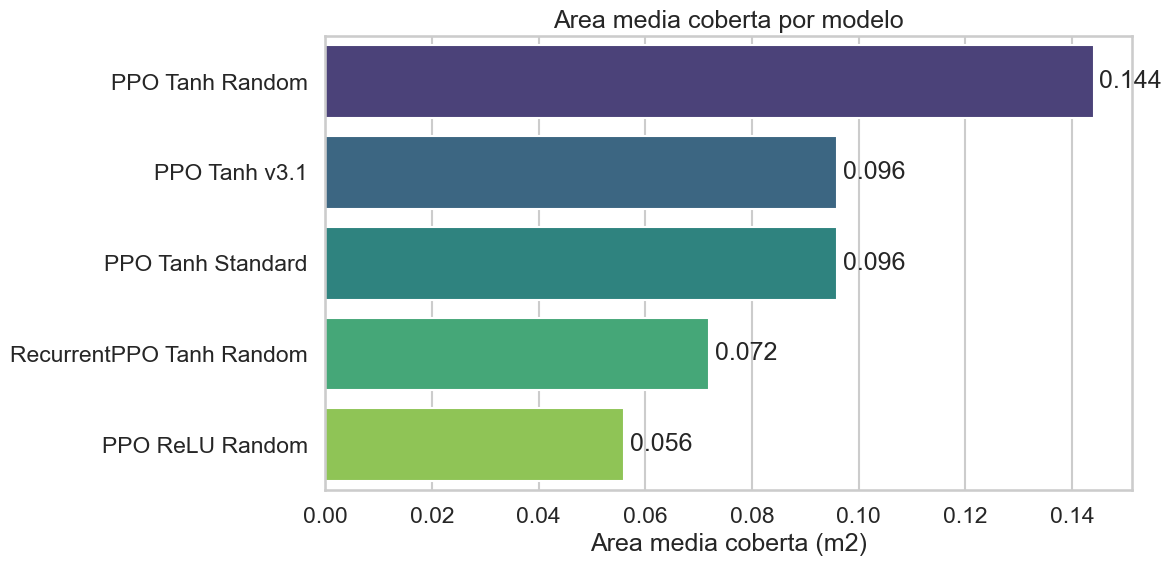

In [3]:
plot_df = main.sort_values("mean_covered_area_m2", ascending=False)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=plot_df,
    x="mean_covered_area_m2",
    y="label",
    palette="viridis",
)
ax.set_title("Area media coberta por modelo")
ax.set_xlabel("Area media coberta (m2)")
ax.set_ylabel("")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=4)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_area_media_modelos.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. Eventos de seguranca

Compara colisoes, quedas e terminacoes por cliff/stuck. Este grafico e bom para mostrar que alguns modelos exploram pouco, mas tambem evitaram eventos graves.

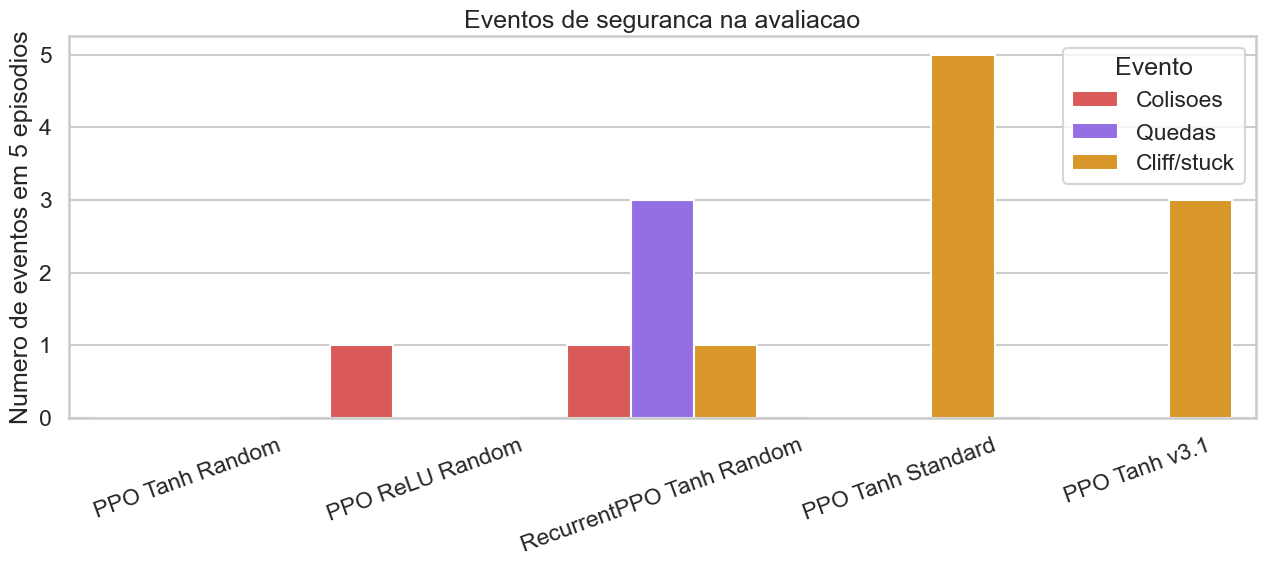

In [4]:
safety_long = main.melt(
    id_vars=["label"],
    value_vars=["total_collisions", "total_falls", "total_cliff_terminations"],
    var_name="event_type",
    value_name="count",
)

event_labels = {
    "total_collisions": "Colisoes",
    "total_falls": "Quedas",
    "total_cliff_terminations": "Cliff/stuck",
}
safety_long["event_type"] = safety_long["event_type"].map(event_labels)

plt.figure(figsize=(13, 6))
ax = sns.barplot(
    data=safety_long,
    x="label",
    y="count",
    hue="event_type",
    palette=["#ef4444", "#8b5cf6", "#f59e0b"],
)
ax.set_title("Eventos de seguranca na avaliacao")
ax.set_xlabel("")
ax.set_ylabel("Numero de eventos em 5 episodios")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Evento")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_eventos_seguranca.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Area vs eventos de seguranca

Este e provavelmente o grafico mais forte para discussao: mostra o compromisso entre explorar mais e falhar menos.

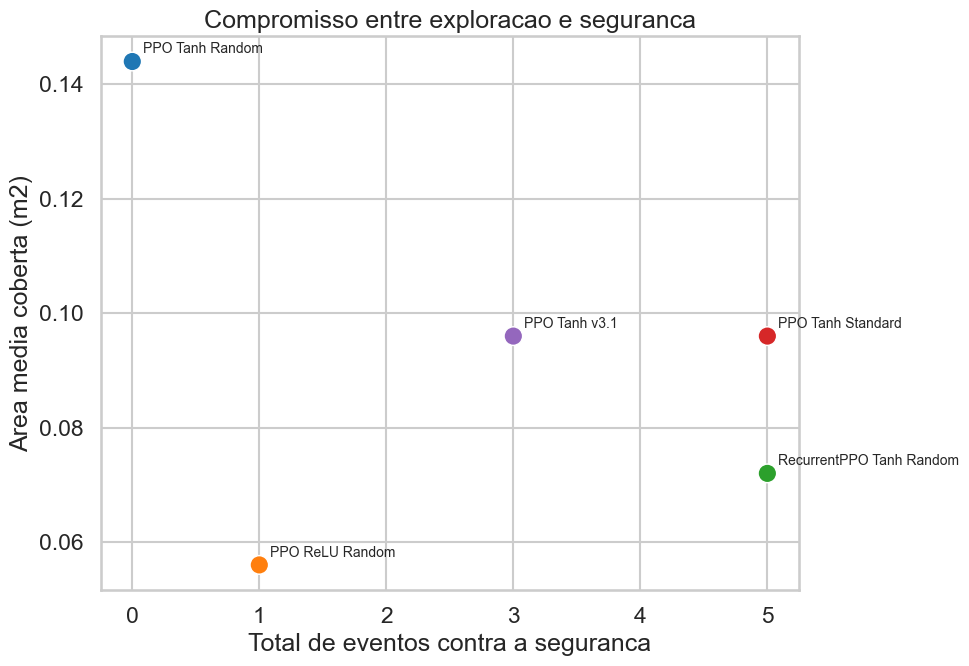

In [6]:
plt.figure(figsize=(10, 7))
ax = sns.scatterplot(
    data=main,
    x="total_safety_events",
    y="mean_covered_area_m2",
    hue="label",
    s=180,
    palette="tab10",
)

for _, row in main.iterrows():
    ax.annotate(
        row["label"],
        (row["total_safety_events"], row["mean_covered_area_m2"]),
        textcoords="offset points",
        xytext=(8, 6),
        fontsize=10,
    )

ax.set_title("Compromisso entre exploracao e seguranca")
ax.set_xlabel("Total de eventos contra a seguranca")
ax.set_ylabel("Area media coberta (m2)")
ax.legend().remove()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_area_vs_eventos.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Evolucao media da reward

Este grafico deve ser usado com cuidado, porque a reward mudou entre algumas versoes. Ainda assim, ajuda a mostrar se cada treino melhorou ou piorou internamente.

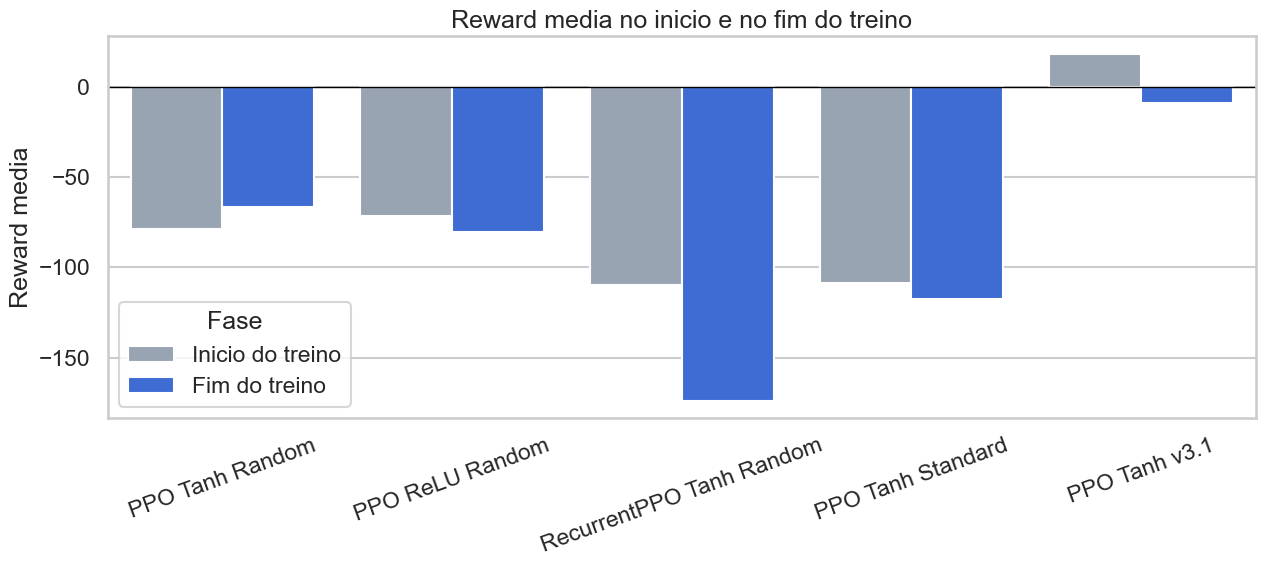

In [7]:
reward_long = main.melt(
    id_vars=["label"],
    value_vars=["mean_reward_start", "mean_reward_end"],
    var_name="stage",
    value_name="mean_reward",
)
reward_long["stage"] = reward_long["stage"].map({
    "mean_reward_start": "Inicio do treino",
    "mean_reward_end": "Fim do treino",
})

plt.figure(figsize=(13, 6))
ax = sns.barplot(
    data=reward_long,
    x="label",
    y="mean_reward",
    hue="stage",
    palette=["#94a3b8", "#2563eb"],
)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Reward media no inicio e no fim do treino")
ax.set_xlabel("")
ax.set_ylabel("Reward media")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Fase")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_reward_inicio_fim.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Tabela final para copiar para o relatorio

In [8]:
summary_table = main[[
    "label",
    "model",
    "activation",
    "environment",
    "training_timesteps",
    "mean_covered_area_m2",
    "total_collisions",
    "total_falls",
    "total_cliff_terminations",
    "reward_improvement",
    "visual_observation",
]].copy()

summary_table = summary_table.rename(columns={
    "label": "Modelo",
    "model": "Algoritmo",
    "activation": "Ativacao",
    "environment": "Ambiente treino",
    "training_timesteps": "Timesteps",
    "mean_covered_area_m2": "Area media (m2)",
    "total_collisions": "Colisoes",
    "total_falls": "Quedas",
    "total_cliff_terminations": "Cliff/stuck",
    "reward_improvement": "Melhoria reward",
    "visual_observation": "Observacao visual",
})

summary_table.to_csv(FIGURES_DIR / "tabela_resumo_modelos.csv", index=False)
summary_table

,Modelo,Algoritmo,Ativacao,Ambiente treino,Timesteps,Area media (m2),Colisoes,Quedas,Cliff/stuck,Melhoria reward,Observacao visual
0,PPO Tanh Random,PPO,Tanh,random,50000,0.144,0,0,0.0,12.286626,Maior area e zero eventos; visualmente conserv...
1,PPO ReLU Random,PPO,ReLU,random,50000,0.056,1,0,0.0,-9.304438,"Recuava ao chegar ao precipicio de frente, mas..."
2,RecurrentPPO Tanh Random,RecurrentPPO,Tanh,random,50000,0.072,1,3,1.0,-64.010142,Movimento curvo para a direita; continuou com ...
3,PPO Tanh Standard,PPO,Tanh,standard,50000,0.096,0,0,5.0,-9.358368,Treinado em standard e avaliado em random; and...
4,PPO Tanh v3.1,PPO,Tanh,random,20480,0.096,0,0,3.0,-27.214971,"Fazia curvas, mas terminava cedo por cliff war..."
